# Machine Learning 1
# Introduction & Supervised Learning

## DataPy - Week 9

# Review & Context

## Previous Topics

- ✓ Python Fundamentals (Week 1-3)
- ✓ NumPy & Arrays (Week 4)  
- ✓ Pandas & DataFrames (Week 5)
- ✓ Data Cleaning (Week 7)
- ✓ Visualization (Week 8)

## Today

**Train ML models with the cleaned data!**

<img src="images/AI_ML.png" style="float: right; width: 30%; margin-left: 20px;">


# What is Machine Learning?

## Difference to Classical Programming

| Classical (rule-based) | Machine Learning |
|-----------|------------------|
| We write rules | Computer learns rules |
| `if price > 250: ...` | Model finds patterns |
| Static | Adaptive |
| Maintenance-intensive | Scalable |

> **Machine Learning** = Computer learns from data, without being explicitly programmed!



<img src="images/ML_vs_DL.png">


- ML: ideal for analyzing structured data - e.g. analyzing lab values, vital parameters, medical history data of patients to make predictions for certain disease risks.
- DL: mainly used for unstructured data like images or speech - e.g. detecting tumors in MRI scans or automatically evaluating X-ray images.

--> **We focus on ML!**

# Example: Spam Filter

## Rule-based Approach (Classical)

```python
def is_spam(email):
    spam_words = ['Viagra', 'Win', 'Click here']
    score = 0
    
    for word in spam_words:
        if word in email:
            score += 1
    
    return score > 2
```

**Problem:** 
- Manually define rules
- Spam emails constantly change
- Not scalable

# Example: Spam Filter with ML

## Machine Learning Approach


```python
# 1. Load training data
emails = pd.read_csv('emails.csv') # Columns: text, is_spam

# 2. Train model
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()
model.fit(emails['text'], emails['is_spam'])

# 3. Classify new email
new_email = "You won 1 million dollars!"
model.predict([new_email])  # → Spam!
```


**Advantage:** Learns automatically from examples!

<img src="images/ML1.png" style="float: left; width: 30%; margin-right: 50px;">

# Why Machine Learning?

## Advantages

✅ **Automation:** Rules are learned from data  
✅ **Scalability:** Works with large amounts of data  
✅ **Adaptability:** Learns from new data  
✅ **Complexity:** Can find patterns we don't see

---

<img src="images/ml-pipeline.png" style="float: right; width: 50%; margin-right: 50px;">

## Applications

- Spam filters
- Product recommendations (Netflix, Amazon)
- Facial recognition
- Medical diagnoses
- **Airbnb price prediction** 🏠

# Types of Machine Learning

<img src="images/ML_subgroups_.png" style="float: right; width: 40%; margin-left: 20px;">

## 1. Supervised Learning
- We have **labels** (correct answers)
- Example: Spam/Not-Spam, Price, Disease/Healthy

## 2. Unsupervised Learning
- No labels
- Example: Find customer groups, topics in texts

## 3. Reinforcement Learning
- Learning through reward/punishment
- Example: Playing chess, robot control

---

**Today we focus on Supervised Learning!**

# Supervised Learning in Detail

## Two Main Types

### 1. **Classification**
- **Goal: Predict category**
- **Examples:**
  - Spam vs. Not-Spam
  - Disease present: Yes/No
  - Airbnb room_type: Entire home / Private room / Shared room

### 2. **Regression**
- **Goal: Predict continuous value**
- **Examples:**
  - Tomorrow's temperature
  - Stock price
  - Airbnb price in €

# ML Terminology

## Important Terms

| Term | Meaning | Example (Airbnb) |
|---------|-----------|-------------------|
| **Features** (X) | Input variables | bedrooms, location, amenities |
| **Target/Label** (y) | What we want to predict | price |
| **Training** | Model learns from data | .fit() |
| **Prediction** | Model makes predictions | .predict() |
| **Sample/Row** | One observation | One Airbnb listing |

```python
# X = Features (multiple columns)
X = df[['bedrooms', 'bathrooms', 'accommodates']]

# y = Target (one column)
y = df['price']
```

# The Biggest Problem in ML: Overfitting

## What is Overfitting?

> Model **memorizes training data** instead of learning general patterns

## Analogy: Exam Preparation

| Good Learning | Overfitting |
|--------------|-------------|
| Understand concepts | Memorize practice problems |
| Answer new questions | Only answer known questions |
| **Generalization** | **Memorization** |

# Train/Test Split

## The Solution Against Overfitting

**Idea:** Split data into two parts

```
Total Data (100%)
├── Training Set (70-80%)
│   └── Model learns here
└── Test Set (20-30%)
    └── Model is evaluated here
```

## Important!

❌ **WRONG:** Test model on training data  
✅ **RIGHT:** Test model on test data (it has never seen)

In [3]:
# Train/Test Split in sklearn

# QUESTION: What would an Airbnb accommodation with certain features cost per night?
# 
# Example: An apartment with 2 bedrooms, space for 4 guests
# → ML model learns from thousands of Airbnb listings
# → and makes prediction: approx. 80€ per night
#
# Features (X): bedrooms, accommodates
# Target (y): price (continuous value)
# Problem type: Regression (number prediction)

from sklearn.model_selection import train_test_split
import pandas as pd

# 1. Load cleaned data (cleaned from Week 7!)
df = pd.read_csv('airbnb_berlin_cleaned.csv')

# 2. Define Features (X) and Target (Y)
X = df[['bedrooms', 'accommodates']]  # Input variables
y = df['price_num']  # What we want to predict

# 3. Split data into Train and Test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,  # 20% for testing
    random_state=42  # Reproducibility
)

print(f"Training: {len(X_train)} samples")
print(f"Testing: {len(X_test)} samples")

Training: 11419 samples
Testing: 2855 samples


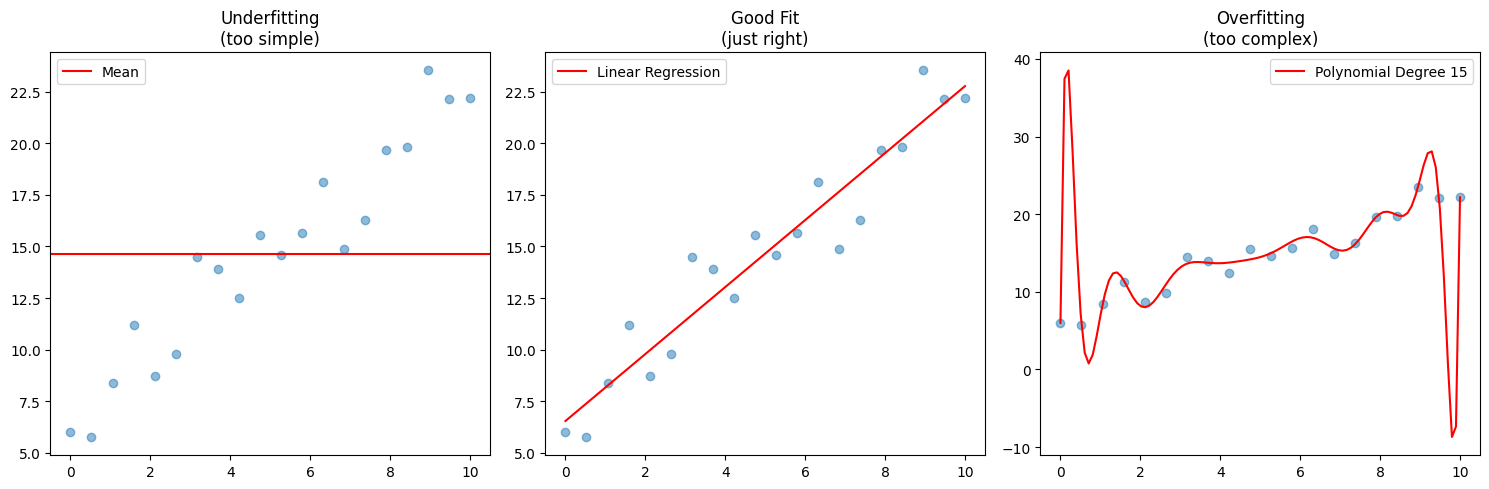

In [4]:
# Visualization: Overfitting

import matplotlib.pyplot as plt
import numpy as np

# Simple example: Polynomial Regression
np.random.seed(42)  # seed --> Same starting value = same "random" numbers
X = np.linspace(0, 10, 20)  # 20 points, from 0 to 10
y = 2*X + 5 + np.random.randn(20)*2  # Straight line + noise

plt.figure(figsize=(15, 5))

# Plot 1: Underfitting (too simple)
plt.subplot(1, 3, 1)
plt.scatter(X, y, alpha=0.5)
plt.axhline(y.mean(), color='r', label='Mean')  # Model: Only average of all y-values, ignores X completely
plt.title('Underfitting\n(too simple)')
plt.legend()

# Plot 2: Good Fit
plt.subplot(1, 3, 2)
plt.scatter(X, y, alpha=0.5)
z = np.polyfit(X, y, 1)  # Degree 1 = straight line
p = np.poly1d(z)  # Creates function
plt.plot(X, p(X), 'r-', label='Linear Regression')  # Draws line. Model: Simple straight line (like real data!)
plt.title('Good Fit\n(just right)')
plt.legend()

# Plot 3: Overfitting (too complex)
plt.subplot(1, 3, 3)
plt.scatter(X, y, alpha=0.5)
z = np.polyfit(X, y, 15)  # Degree 15 = Very curved!
p = np.poly1d(z)
X_smooth = np.linspace(0, 10, 100)  # 100 points for smooth curve
plt.plot(X_smooth, p(X_smooth), 'r-', label='Polynomial Degree 15')  # Model: Degree 15 polynomial (extremely curved). Problem: Goes through EVERY point, even noise
plt.title('Overfitting\n(too complex)')
plt.legend()

plt.tight_layout()
plt.show()

# Our First ML Algorithm: Nearest Centroid Classifier (NCC)

## Basic Idea (very simple!)

1. **Training:** Calculate the mean (centroid) of each class
2. **Prediction:** New data point → Which centroid is closest?

In [7]:
import numpy as np

def fit_ncc(X_train, y_train):
    """Train NCC: Calculate centroids"""
    classes = np.unique(y_train)
    centroids = {}
    
    for c in classes:
        # Mean of all points in this class
        mask = (y_train == c)
        centroids[c] = X_train[mask].mean(axis=0)
    
    return centroids, classes

def predict_ncc(X_test, centroids, classes):
    """Prediction: Find nearest centroid"""
    predictions = []
    
    for x in X_test:
        # Calculate distance to all centroids
        distances = {}
        for c in classes:
            dist = np.linalg.norm(x - centroids[c])
            distances[c] = dist
        
        # Predict class with smallest distance
        pred = min(distances, key=distances.get)
        predictions.append(pred)
    
    return np.array(predictions)

In [8]:
import numpy as np
from sklearn.model_selection import train_test_split
import pandas as pd

# 1. Prepare data
df = pd.read_csv('airbnb_berlin_cleaned.csv')
df_model = df[['bedrooms', 'accommodates', 'room_type']].dropna()

X = df_model[['bedrooms', 'accommodates']].values
y = df_model['room_type'].values

# 2. Train/Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Training
centroids, classes = fit_ncc(X_train, y_train)

# 4. Prediction
y_pred = predict_ncc(X_test, centroids, classes)

# 5. Evaluation
accuracy = (y_pred == y_test).mean()
print(f"Accuracy: {accuracy:.2%}")

Accuracy: 29.10%


# sklearn: The Standard for ML in Python

## What is scikit-learn?

- **THE** ML library for Python
- Unified API for all algorithms
- Well documented and tested

## Installation

```bash
pip install scikit-learn
```

## Basic Principle: fit() and predict()

```python
from sklearn.some_algorithm import SomeModel

model = SomeModel()
model.fit(X_train, y_train)      # Training
predictions = model.predict(X_test)  # Prediction
```

In [11]:
# sklearn: NCC Example

from sklearn.neighbors import NearestCentroid
from sklearn.model_selection import train_test_split

# Prepare data
df = pd.read_csv('airbnb_berlin_cleaned.csv')
X = df[['bedrooms', 'accommodates']].dropna()
y = df.loc[X.index, 'room_type']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create and train model
model = NearestCentroid()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = model.score(X_test, y_test)
print(f"Accuracy: {accuracy:.2%}")

Accuracy: 29.10%


# sklearn: Try Other Algorithms

## The API is Always the Same!

```python
# K-Nearest Neighbors (KNN)
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)
print(f"KNN Accuracy: {model.score(X_test, y_test):.2%}")

# Decision Tree
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(max_depth=5)
model.fit(X_train, y_train)
print(f"Tree Accuracy: {model.score(X_test, y_test):.2%}")

# Logistic Regression
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
print(f"LogReg Accuracy: {model.score(X_test, y_test):.2%}")
```

# Evaluation: Accuracy

## What is Accuracy?

$$\text{Accuracy} = \frac{\text{Number of correct predictions}}{\text{Total number of predictions}}$$

## Example

- 100 test samples
- 75 correctly predicted
- **Accuracy = 75%**

```python
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2%}")

# Or directly:
accuracy = model.score(X_test, y_test)
```

# Summary

## What We Learned Today

✅ **What is Machine Learning?**  
  → Computer learns from data

✅ **Supervised Learning**  
  → Classification vs. Regression

✅ **Train/Test Split**  
  → Against overfitting!

✅ **Nearest Centroid Classifier**  
  → Understood simple algorithm

✅ **sklearn Workflow**  
  → `.fit()`, `.predict()`, `.score()`

# Next part (optional): Machine Learning II

## Advanced Topics

- 📊 **Evaluation Metrics**: Precision, Recall, F1, Confusion Matrix
- 🔍 **Model Comparison**: Which algorithm is better?
- 🎯 **Feature Engineering**: Better features = Better model
- 🚀 **Outlook**: BERT & Transformer (State-of-the-Art)


# Next week

## Streamlit Introduction
- Building a simple Streamlit app
- Loading prepared data, simple visualization

# Tasks for Today

## Exercise Notebooks

### 1. Airbnb Example (work on in exercise session)
- Classify room_type
- Compare various algorithms
- Apply Train/Test Split

### 2. Project work: Find exciting question and apply, e.g. for Heart Disease:
- Predict disease (Classification)
- Evaluate models
- Create visualizations (Heatmap etc.)

# Resources

## 📚 Documentation
- [scikit-learn User Guide](https://scikit-learn.org/stable/user_guide.html)
- [scikit-learn Cheat Sheet](https://scikit-learn.org/stable/tutorial/machine_learning_map/)

## 🎓 Tutorials
- [Kaggle Learn: Intro to Machine Learning](https://www.kaggle.com/learn/intro-to-machine-learning)
- [Google ML Crash Course](https://developers.google.com/machine-learning/crash-course)

## 📖 Books
- "Hands-On Machine Learning" (Géron)
- "Introduction to Statistical Learning" (James et al.)